# MAG Energy Solutions — 2-Stage Opportunity Selection
## Data Challenge 2026

**Architecture**: Stage 1 (RF Classifier → filters profitable opportunities) → Stage 2 (LightGBM + XGBoost Regressor ensemble → ranks by expected profit)

**Key design principles**:
- Strict temporal anti-leakage (cutoff = 7th of month M)
- Walk-forward expanding-window cross-validation
- Stage 2 trained on OOF predictions only (proper stacking)
- Final scoring: `EV = rf_prob × max(0, predicted_profit)` to jointly optimize F1 and profit


In [ ]:
%pip install lightgbm xgboost --quiet

In [1]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================
import os
import gc
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    mean_absolute_error, r2_score
)
import lightgbm as lgb
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

print("Imports OK")


Imports OK


In [3]:
# ============================================================
# CELL 3 — LOAD MASTER DATASET
# ============================================================
# Supports: pre-loaded variable 'master' or 'df', or parquet from DATA_PATH env var.
# Set DATA_PATH environment variable or edit MASTER_PATH below.

MONTH_COL = "MONTH"

MASTER_PATH = os.environ.get(
    "DATA_PATH",
    "D:/Data Challenge/master_dataset.parquet"   # relative path — edit if needed
)

if "master" in globals():
    full_df = master.copy()
    print("Loaded from 'master' variable")
elif "df" in globals():
    full_df = df.copy()
    print("Loaded from 'df' variable")
else:
    print(f"Loading from: {MASTER_PATH}")
    full_df = pd.read_parquet(MASTER_PATH)

# Coerce types
full_df[MONTH_COL] = full_df[MONTH_COL].astype(str)
full_df["TARGET"]  = full_df["TARGET"].astype(int)
full_df["PROFIT"]  = pd.to_numeric(full_df["PROFIT"], errors="coerce").fillna(0.0)

print(f"Shape: {full_df.shape}")
print(f"Months: {full_df[MONTH_COL].min()} → {full_df[MONTH_COL].max()}")
print(f"Positives: {full_df['TARGET'].sum():,} / {len(full_df):,} "
      f"({100 * full_df['TARGET'].mean():.2f}%)")
full_df[[MONTH_COL, "TARGET", "PROFIT"]].head(5)


Loading from: D:/Data Challenge/master_dataset.parquet
Shape: (211510, 71)
Months: 2020-01 → 2023-12
Positives: 15,406 / 211,510 (7.28%)


,MONTH,TARGET,PROFIT
0,2020-01,0,0.0000
1,2020-01,0,0.0000
2,2020-01,0,0.0000
3,2020-01,0,0.0000
4,2020-01,0,0.0000


In [4]:
# ============================================================
# CELL 4 — GLOBAL SPLIT
# Train : 2020-01 → 2022-12
# Test  : 2023-01 → 2023-12  (held-out, never touched during tuning)
# ============================================================

TRAIN_END  = "2022-12"
TEST_START = "2023-01"
TEST_END   = "2023-12"

train_df = full_df[full_df[MONTH_COL] <= TRAIN_END].copy()
test_df  = full_df[
    (full_df[MONTH_COL] >= TEST_START) &
    (full_df[MONTH_COL] <= TEST_END)
].copy()

print(f"Train: {train_df[MONTH_COL].min()} → {train_df[MONTH_COL].max()} "
      f"| rows={len(train_df):,} | positives={train_df['TARGET'].sum():,}")
print(f"Test : {test_df[MONTH_COL].min()} → {test_df[MONTH_COL].max()}  "
      f"| rows={len(test_df):,} | positives={test_df['TARGET'].sum():,}")
print(f"\nPositive rate — train: {100*train_df['TARGET'].mean():.2f}% "
      f"| test: {100*test_df['TARGET'].mean():.2f}%")


Train: 2020-01 → 2022-12 | rows=137,642 | positives=11,890
Test : 2023-01 → 2023-12  | rows=73,868 | positives=3,516

Positive rate — train: 8.64% | test: 4.76%


In [5]:
# ============================================================
# CELL 5 — FEATURE LIST
# These columns are excluded from model inputs (leaky / identifier / target).
# ============================================================

DROP_COLS = {
    "EID", "MONTH", "DECISION_MONTH",
    "PR", "PR_signed", "C",
    "PROFIT", "TARGET",
    "season", "season_encoded",
    "is_sim_only", "PEAKID",
    # degenerate columns (duplicated or zero-variance detected earlier)
    "psm_abs_nonzero_std", "psd_abs_nonzero_std",
}

def get_features(df: pd.DataFrame) -> list:
    """Return all numeric/bool columns not in DROP_COLS."""
    num_cols = df.select_dtypes(include=[np.number, bool]).columns.tolist()
    return [c for c in num_cols if c not in DROP_COLS]

FEATURES = get_features(train_df)
print(f"Number of features: {len(FEATURES)}")
print(FEATURES)


Number of features: 57
['pr_partial_current', 'has_pr_history', 'has_profit_history', 'has_cost_history', 'pr_lag1', 'pr_lag2', 'pr_lag3', 'c_lag1', 'profit_lag1', 'profit_lag2', 'target_lag1', 'pr_rolling3_mean', 'profit_rolling3_mean', 'profitable_count_3m', 'psd_nonzero_count', 'psd_abs_nonzero_mean', 'psd_abs_sum', 'psd_signed_mean', 'psd_abs_max', 'activation_mean', 'activation_max', 'activation_nonzero_count', 'wind_abs_mean', 'solar_abs_mean', 'hydro_abs_mean', 'nonrenew_abs_mean', 'external_abs_mean', 'load_abs_mean', 'transoutage_abs_mean', 'hydro_log_abs_mean', 'hydro_abs_max', 'wind_log_abs_mean', 'wind_abs_max', 'load_log_abs_mean', 'load_abs_max', 'psd_abs_s1_mean', 'psd_abs_s23_mean', 'psd_scenario_spread', 'psd_abs_early', 'psd_abs_late', 'psm_nonzero_count', 'psm_abs_nonzero_mean', 'psm_abs_sum', 'psm_signed_mean', 'psm_abs_max', 'psm_activation_mean', 'psm_activation_max', 'psm_wind_abs_mean', 'psm_solar_abs_mean', 'psm_hydro_abs_mean', 'psm_nonrenew_abs_mean', 'psm_ex

In [6]:
# ============================================================
# CELL 6 — WALK-FORWARD EXPANDING-WINDOW CV
# ============================================================
# Each fold trains on all months up to fold boundary, validates on next month.
# This strictly respects temporal ordering — no future data leaks into training.

def make_walkforward_splits(months: list, min_train_months: int = 6,
                            valid_window: int = 1) -> list:
    """
    Expanding-window walk-forward CV.
    Fold i: train on months[:i], validate on months[i:i+valid_window]

    Returns list of (train_months, valid_months) tuples.
    """
    splits = []
    n = len(months)
    for i in range(min_train_months, n - valid_window + 1):
        splits.append((months[:i], months[i: i + valid_window]))
    return splits


train_months_sorted = sorted(
    train_df[MONTH_COL].dropna().astype(str).unique().tolist()
)

splits = make_walkforward_splits(train_months_sorted,
                                 min_train_months=6,
                                 valid_window=1)

print(f"Total folds: {len(splits)}")
for i, (tr, va) in enumerate(splits[:5], 1):
    print(f"  Fold {i:02d}: train {tr[0]}→{tr[-1]} ({len(tr)} months) | valid {va}")
print("  ...")
for i, (tr, va) in enumerate(splits[-3:], len(splits)-2):
    print(f"  Fold {i:02d}: train {tr[0]}→{tr[-1]} ({len(tr)} months) | valid {va}")


Total folds: 30
  Fold 01: train 2020-01→2020-06 (6 months) | valid ['2020-07']
  Fold 02: train 2020-01→2020-07 (7 months) | valid ['2020-08']
  Fold 03: train 2020-01→2020-08 (8 months) | valid ['2020-09']
  Fold 04: train 2020-01→2020-09 (9 months) | valid ['2020-10']
  Fold 05: train 2020-01→2020-10 (10 months) | valid ['2020-11']
  ...
  Fold 28: train 2020-01→2022-09 (33 months) | valid ['2022-10']
  Fold 29: train 2020-01→2022-10 (34 months) | valid ['2022-11']
  Fold 30: train 2020-01→2022-11 (35 months) | valid ['2022-12']


In [7]:
# ============================================================
# CELL 7 — EVALUATION HELPERS
# ============================================================

def per_month_topk_profit(df_val: pd.DataFrame, score_col: str, k: int) -> float:
    """Sum of PROFIT for top-k scored rows per month."""
    total = 0.0
    for _, grp in df_val.groupby(MONTH_COL):
        total += grp.nlargest(k, score_col)["PROFIT"].sum()
    return total


def topk_classification_metrics(df_val: pd.DataFrame, score_col: str,
                                 k: int) -> tuple:
    """
    Compute precision, recall, F1 using top-k selection per month
    as the positive prediction.
    """
    y_true_all, y_pred_all = [], []
    for _, grp in df_val.groupby(MONTH_COL):
        selected = grp.nlargest(k, score_col).index
        pred = np.zeros(len(grp), dtype=int)
        pred[np.isin(grp.index, selected)] = 1
        y_true_all.extend(grp["TARGET"].tolist())
        y_pred_all.extend(pred.tolist())

    y_true = np.array(y_true_all)
    y_pred = np.array(y_pred_all)
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return p, r, f1


def optimize_k(df_val: pd.DataFrame, score_col: str,
               k_min: int = 10, k_max: int = 100) -> tuple:
    """Find k in [k_min, k_max] that maximises per-month total profit."""
    best_k, best_profit = k_min, -np.inf
    for k in range(k_min, k_max + 1):
        p = per_month_topk_profit(df_val, score_col, k)
        if p > best_profit:
            best_profit, best_k = p, k
    return best_k, best_profit


def evaluate_full(df_val: pd.DataFrame, score_col: str, k: int,
                  label: str = "") -> dict:
    """Compute AUC, profit@k, precision, recall, F1 and print summary."""
    auc  = roc_auc_score(df_val["TARGET"], df_val[score_col])
    prof = per_month_topk_profit(df_val, score_col, k)
    p, r, f1 = topk_classification_metrics(df_val, score_col, k)
    print(f"{label:30s} | AUC={auc:.4f} | k={k:3d} | "
          f"Profit={prof:>12,.0f} | P={p:.4f} R={r:.4f} F1={f1:.4f}")
    return {"auc": auc, "profit": prof, "precision": p, "recall": r, "f1": f1, "k": k}

print("Helpers defined.")


Helpers defined.


In [ ]:
# ============================================================
# CELL 20b — LOAD SAVED MODELS & ARTIFACTS (SKIP RETRAINING)
# ============================================================
# Run this cell INSTEAD of Cells 8-19 when models are already trained.
# After running this cell, the notebook resumes normally from Cell 21
# (generate opportunities.csv) onwards.

import joblib
import json as _json
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from xgboost import XGBRegressor

MODELS_DIR = Path("models")

# --- Models ---
final_rf   = joblib.load(MODELS_DIR / "final_rf.joblib")
final_lgbm = joblib.load(MODELS_DIR / "final_lgbm.joblib")
final_xgb  = joblib.load(MODELS_DIR / "final_xgb.joblib")
print("Models loaded.")

# --- Hyperparameters & CV results ---
with open(MODELS_DIR / "best_rf_params.json") as f:
    best_rf_params = _json.load(f)

rf_dev_results = pd.read_parquet(MODELS_DIR / "rf_dev_results.parquet")
best_rf_config_id = int(rf_dev_results.iloc[0]["config_id"])
print("CV results loaded.")

# --- OOF dataframe ---
stage2_oof_df = pd.read_parquet(MODELS_DIR / "stage2_oof_df.parquet")
stage2_train_positives = stage2_oof_df[stage2_oof_df["TARGET"] == 1].copy()
print("OOF dataframe loaded.")

# --- Feature list & config ---
with open(MODELS_DIR / "features.json") as f:
    FEATURES = _json.load(f)

with open(MODELS_DIR / "config.json") as f:
    cfg = _json.load(f)

best_k_final  = cfg["best_k"]
MONTH_COL     = cfg["month_col"]
best_rf_model = final_rf    # alias used in evaluation cells

print("Feature list & config loaded.")
print(f"  Features : {len(FEATURES)}")
print(f"  Best k   : {best_k_final}")
print(f"  Train end: {cfg['train_end']}")
print("\nReady — continue from Cell 21 (generate opportunities.csv).")

In [8]:
# ============================================================
# CELL 8 — STAGE 1: RF HYPERPARAMETER GRID
# ============================================================

rf_grid = [
    {"n_estimators": 300, "max_depth": 6,    "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 8,    "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 10,   "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 8,    "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 10,   "min_samples_leaf": 10, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 20, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": None, "min_samples_leaf": 20, "max_features": "sqrt"},
]

print(f"{len(rf_grid)} RF configurations to evaluate.")


7 RF configurations to evaluate.


In [11]:
# ============================================================
# CELL 9 — STAGE 1: RF WALK-FORWARD TUNING (OPTIMIZED)
# ============================================================
# Speedup strategy:
#   1. Parallel execution across configs (joblib) — ~6-7x faster
#   2. Reduced n_estimators during CV (100 vs 300-500) — ~3x faster
#   3. Pre-cached fold data slices — avoids repeated filtering
#   4. n_jobs=1 per RF (avoids nested parallelism CPU thrashing)
# Best config is then retrained at full n_estimators in Cell 10.

import time
from joblib import Parallel, delayed

# --- Step 1: Pre-cache all fold data slices (computed once, shared across configs) ---
print("Pre-caching fold data slices...")
fold_data = []
for tr_months, va_months in splits:
    df_tr = train_df[train_df[MONTH_COL].isin(tr_months)].copy()
    df_va = train_df[train_df[MONTH_COL].isin(va_months)].copy()
    fold_data.append((tr_months, va_months, df_tr, df_va))
print(f"  {len(fold_data)} folds cached.")

# --- Step 2: Define per-config worker (runs all folds for one config) ---
def run_one_config(config_id, params, fold_data, FEATURES, MONTH_COL,
                   n_estimators_cv=100):
    """
    Run all walk-forward folds for one RF config.
    Uses n_estimators_cv (fast) instead of params["n_estimators"] (full).
    n_jobs=1 inside RF — outer parallelism handles concurrency.
    """
    fast_params = {**params, "n_estimators": n_estimators_cv}

    fold_rows = []
    oof_parts = []

    for fold_id, (tr_months, va_months, df_tr, df_va) in enumerate(fold_data, start=1):
        if len(df_tr) == 0 or len(df_va) == 0:
            continue

        rf = RandomForestClassifier(
            **fast_params,
            n_jobs=1,           # 1 here — outer Parallel handles concurrency
            random_state=42,
            class_weight="balanced_subsample"
        )
        rf.fit(df_tr[FEATURES], df_tr["TARGET"])

        df_va = df_va.copy()
        df_va["rf_prob"] = rf.predict_proba(df_va[FEATURES])[:, 1]

        auc = roc_auc_score(df_va["TARGET"], df_va["rf_prob"])
        best_k, best_profit = optimize_k(df_va, "rf_prob", 10, 100)
        p_at_k, r_at_k, f1_at_k = topk_classification_metrics(
            df_va, "rf_prob", best_k)

        fold_rows.append({
            "config_id": config_id, "fold_id": fold_id,
            "train_end": tr_months[-1], "valid_month": va_months[0],
            "auc": auc, "best_k": best_k, "best_profit": best_profit,
            "prec_at_k": p_at_k, "rec_at_k": r_at_k, "f1_at_k": f1_at_k
        })

        oof_row = df_va[["EID", MONTH_COL, "PEAKID",
                         "TARGET", "PROFIT", "rf_prob"] + FEATURES].copy()
        oof_parts.append(oof_row)

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "config_id": config_id,
        "params": params,
        "mean_auc": fold_df["auc"].mean(),
        "mean_best_profit": fold_df["best_profit"].mean(),
        "mean_f1_at_k": fold_df["f1_at_k"].mean(),
        "mean_best_k": int(round(fold_df["best_k"].mean())),
        "std_profit": fold_df["best_profit"].std(),
    }
    oof_df = pd.concat(oof_parts, ignore_index=True)
    return config_id, summary, oof_df, fold_df

# --- Step 3: Run all configs in parallel ---
N_JOBS_OUTER = -1       # use all available cores
N_ESTIMATORS_CV = 100   # fast CV trees; best config retrained at full size in Cell 10

print(f"\nRunning {len(rf_grid)} configs × {len(fold_data)} folds in parallel")

print(f"  n_estimators during CV : {N_ESTIMATORS_CV} (full size used in Cell 10)")
print(f"  outer n_jobs           : {N_JOBS_OUTER}")

t0 = time.time()

parallel_results = Parallel(n_jobs=N_JOBS_OUTER, verbose=5)(
    delayed(run_one_config)(
        config_id, params, fold_data, FEATURES, MONTH_COL, N_ESTIMATORS_CV
    )
    for config_id, params in enumerate(rf_grid)
)

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s  ({elapsed/60:.1f} min)")


# --- Step 4: Collect results ---
rf_dev_results   = []
rf_dev_oof_store = {}
rf_dev_fold_store = {}

for config_id, summary, oof_df, fold_df in sorted(parallel_results, key=lambda x: x[0]):
    rf_dev_results.append(summary)
    rf_dev_oof_store[config_id]  = oof_df
    rf_dev_fold_store[config_id] = fold_df

rf_dev_results = (
    pd.DataFrame(rf_dev_results)
    .sort_values(["mean_best_profit", "mean_auc"], ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 90)

print("STAGE 1 TUNING SUMMARY (sorted by mean profit)")
print(rf_dev_results[[
    "config_id", "mean_auc", "mean_best_profit",
    "std_profit", "mean_f1_at_k", "mean_best_k", "params"
]].to_string(index=False))


Pre-caching fold data slices...
  30 folds cached.

Running 7 configs × 30 folds in parallel
  n_estimators during CV : 100 (full size used in Cell 10)
  outer n_jobs           : -1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   7 | elapsed: 11.4min remaining: 28.6min
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed: 13.0min remaining:  9.7min
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed: 17.9min finished



Done in 1073.4s  (17.9 min)

STAGE 1 TUNING SUMMARY (sorted by mean profit)
 config_id  mean_auc  mean_best_profit   std_profit  mean_f1_at_k  mean_best_k                                                                                   params
         1    0.8237      163,071.2209 110,191.7831        0.2691           88    {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
         3    0.8237      163,071.2209 110,191.7831        0.2691           88    {'n_estimators': 500, 'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
         5    0.8255      162,004.8544  95,265.6377        0.2654           87 {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 20, 'max_features': 'sqrt'}
         6    0.8255      162,004.8544  95,265.6377        0.2654           87 {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 20, 'max_features': 'sqrt'}
         2    0.8247      158,210.4253 102,197.7521        0.2744           89   {'

In [12]:
# ============================================================
# CELL 10 — BEST RF: FIT ON FULL TRAIN, EVALUATE ON 2023 HOLDOUT
# ============================================================

best_rf_row      = rf_dev_results.iloc[0]
best_rf_config_id = int(best_rf_row["config_id"])
best_rf_params   = best_rf_row["params"]
best_k_rf        = int(best_rf_row["mean_best_k"])

print(f"Best RF config_id : {best_rf_config_id}")
print(f"Best RF params    : {best_rf_params}")
print(f"K chosen from CV  : {best_k_rf}")

# Fit on all train data
best_rf_model = RandomForestClassifier(
    **best_rf_params,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)
best_rf_model.fit(train_df[FEATURES], train_df["TARGET"])

# Score test
test_scored = test_df.copy()
test_scored["rf_prob"] = best_rf_model.predict_proba(test_scored[FEATURES])[:, 1]

print("\n── 2023 HOLDOUT — Stage 1 RF only ──")
rf_test_metrics = evaluate_full(test_scored, "rf_prob", best_k_rf, label="RF Stage-1")


Best RF config_id : 1
Best RF params    : {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
K chosen from CV  : 88

── 2023 HOLDOUT — Stage 1 RF only ──
RF Stage-1                     | AUC=0.8588 | k= 88 | Profit=   1,539,400 | P=0.5644 R=0.1695 F1=0.2607


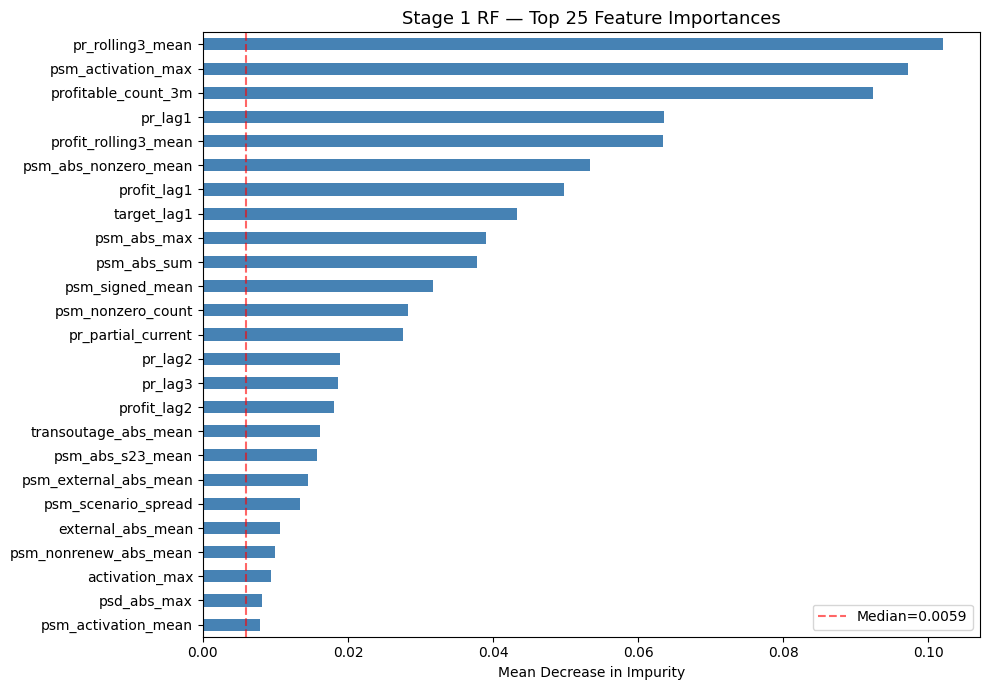


Top 15 features:
pr_rolling3_mean       0.1020
psm_activation_max     0.0972
profitable_count_3m    0.0923
pr_lag1                0.0635
profit_rolling3_mean   0.0634
psm_abs_nonzero_mean   0.0534
profit_lag1            0.0497
target_lag1            0.0433
psm_abs_max            0.0391
psm_abs_sum            0.0378
psm_signed_mean        0.0317
psm_nonzero_count      0.0283
pr_partial_current     0.0276
pr_lag2                0.0189
pr_lag3                0.0186


In [13]:
# ============================================================
# CELL 11 — FEATURE IMPORTANCE (Stage 1 RF)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

fi = pd.Series(best_rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
top_n = 25

fig, ax = plt.subplots(figsize=(10, 7))
fi.head(top_n).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(f"Stage 1 RF — Top {top_n} Feature Importances", fontsize=13)
ax.set_xlabel("Mean Decrease in Impurity")
ax.axvline(fi.median(), color="red", linestyle="--", alpha=0.6, label=f"Median={fi.median():.4f}")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(fi.head(15).to_string())


In [15]:
# ============================================================
# CELL 12 — BUILD OOF DATASET FOR STAGE 2 (OPTIMIZED)
# ============================================================
# Speedup vs original:
#   1. Reuses fold_data cache from Cell 9 — no redundant DataFrame filtering
#   2. Parallelizes folds — each fold is fully independent
#   3. n_jobs=1 per RF to avoid nested parallelism
# Note: best_rf_params still used at FULL n_estimators here (not CV-reduced),
#       because OOF quality directly determines Stage 2 training signal.

import time
from joblib import Parallel, delayed

def build_oof_fold(fold_id, tr_months, va_months, df_tr, df_va,
                   best_rf_params, FEATURES, MONTH_COL):
    """Fit best RF on one fold, return OOF predictions for df_va."""
    if len(df_tr) == 0 or len(df_va) == 0:
        return None

    rf = RandomForestClassifier(
        **best_rf_params,
        n_jobs=1,           # outer Parallel handles concurrency
        random_state=42,
        class_weight="balanced_subsample"
    )
    rf.fit(df_tr[FEATURES], df_tr["TARGET"])

    df_va = df_va.copy()
    df_va["rf_prob"] = rf.predict_proba(df_va[FEATURES])[:, 1]

    return df_va[["EID", MONTH_COL, "PEAKID", "TARGET", "PROFIT",
                  "rf_prob"] + FEATURES].copy()


print("Building OOF dataset (parallelized)...")
t0 = time.time()

oof_results = Parallel(n_jobs=-1, verbose=3)(
    delayed(build_oof_fold)(
        fold_id, tr_months, va_months, df_tr, df_va,
        best_rf_params, FEATURES, MONTH_COL
    )
    for fold_id, (tr_months, va_months, df_tr, df_va) in enumerate(fold_data, start=1)
)

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s  ({elapsed/60:.1f} min)")

# Drop any None results (empty folds) and concatenate
oof_parts = [r for r in oof_results if r is not None]

stage2_oof_df = (
    pd.concat(oof_parts, ignore_index=True)
    .sort_values([MONTH_COL, "EID", "PEAKID"])
    .reset_index(drop=True)
)

# Stage 2 trains ONLY on profitable (TARGET=1) rows from OOF
stage2_train_positives = stage2_oof_df[stage2_oof_df["TARGET"] == 1].copy()

print(f"\nOOF total rows      : {len(stage2_oof_df):,}")
print(f"OOF positive rows   : {len(stage2_train_positives):,} "
      f"({100*len(stage2_train_positives)/len(stage2_oof_df):.2f}%)")
print("PROFIT stats (positives):")
print(stage2_train_positives["PROFIT"].describe())


Building OOF dataset (parallelized)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 out of  30 | elapsed:  3.2min remaining:  2.1min
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:  5.8min finished


Done in 347.4s  (5.8 min)

OOF total rows      : 123,595
OOF positive rows   : 10,442 (8.45%)
PROFIT stats (positives):
count    10,442.0000
mean      2,539.2333
std       7,312.9323
min           0.0059
25%          86.8274
50%         395.0975
75%       1,701.4393
max     119,741.6172
Name: PROFIT, dtype: float64


In [27]:
X_s2 = stage2_oof_df[FEATURES]    # ALL OOF rows
y_s2 = stage2_oof_df["PROFIT"]    # includes negatives — intentional

print(f"Stage 2 training set : {len(X_s2):,} rows, {len(FEATURES)} features")
print(f"  profitable (y > 0) : {int((y_s2 > 0).sum()):,} ({100*(y_s2>0).mean():.1f}%)")
print(f"  loss       (y <= 0): {int((y_s2 <= 0).sum()):,} ({100*(y_s2<=0).mean():.1f}%)")

# --- LightGBM ---
lgbm_reg = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.04,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgbm_reg.fit(X_s2, y_s2)
print("\nLightGBM regressor fitted.")

# --- XGBoost ---
xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    verbosity=0
)
xgb_reg.fit(X_s2, y_s2)
print("XGBoost regressor fitted.")


Stage 2 training set : 123,595 rows, 57 features
  profitable (y > 0) : 10,442 (8.4%)
  loss       (y <= 0): 113,153 (91.6%)

LightGBM regressor fitted.
XGBoost regressor fitted.


In [29]:
# ============================================================
# CELL 14 — STAGE 2 REGRESSION QUALITY CHECK (TRUE OOF)
# ============================================================
# FIX: Use cross_val_predict on ALL rows for honest out-of-sample metrics.
# Previous version evaluated in-sample on positives only → fake R²=0.88.

from sklearn.model_selection import cross_val_predict

X_val_s2 = stage2_oof_df[FEATURES]
y_val_s2  = stage2_oof_df["PROFIT"]

print("── Stage 2 true OOF quality (5-fold CV) ──\n")
for name, model in [("LightGBM", lgbm_reg), ("XGBoost", xgb_reg)]:
    preds    = cross_val_predict(model, X_val_s2, y_val_s2, cv=5, n_jobs=-1)
    mae      = mean_absolute_error(y_val_s2, preds)
    r2       = r2_score(y_val_s2, preds)
    sign_acc = np.mean((preds > 0) == (y_val_s2 > 0))
    # Among rows predicted profitable, what share of total available profit is captured?
    mask_pred_pos       = preds > 0
    profit_captured     = y_val_s2[mask_pred_pos].sum()
    profit_total        = y_val_s2[y_val_s2 > 0].sum()
    profit_capture_rate = profit_captured / profit_total if profit_total > 0 else 0
    print(f"  {name:10s} | MAE={mae:>10,.2f} | R²={r2:.4f} | "
          f"Sign acc={sign_acc:.4f} | Profit capture={profit_capture_rate:.2%}")

print("\nExpected: R² ~0.1-0.4, sign acc ~0.60-0.75 — realistic OOF signal.")
print("If sign acc is still >0.95, Stage 2 is overfitting — reduce n_estimators.")


── Stage 2 true OOF quality (5-fold CV) ──

  LightGBM   | MAE=    414.23 | R²=-0.0078 | Sign acc=0.1360 | Profit capture=55.82%
  XGBoost    | MAE=    418.34 | R²=-0.0296 | Sign acc=0.1304 | Profit capture=53.60%

Expected: R² ~0.1-0.4, sign acc ~0.60-0.75 — realistic OOF signal.
If sign acc is still >0.95, Stage 2 is overfitting — reduce n_estimators.


In [30]:
# ============================================================
# CELL 15 — SCORE 2023 HOLDOUT WITH FULL 2-STAGE PIPELINE
# ============================================================
# test_scored already has rf_prob from Cell 10.
# We add Stage 2 profit predictions and compute Expected Value scores.

test_scored = test_scored.copy()

test_scored["lgbm_profit_pred"] = lgbm_reg.predict(test_scored[FEATURES])
test_scored["xgb_profit_pred"]  = xgb_reg.predict(test_scored[FEATURES])
test_scored["ens_profit_pred"]  = (
    test_scored["lgbm_profit_pred"] + test_scored["xgb_profit_pred"]
) / 2.0

# Expected-Value scores: rf_prob × max(0, predicted_profit)
# This jointly optimises F1 (via rf_prob) and profit (via profit_pred).
test_scored["lgbm_ev"] = test_scored["rf_prob"] * np.maximum(0, test_scored["lgbm_profit_pred"])
test_scored["xgb_ev"]  = test_scored["rf_prob"] * np.maximum(0, test_scored["xgb_profit_pred"])
test_scored["ens_ev"]  = test_scored["rf_prob"] * np.maximum(0, test_scored["ens_profit_pred"])

# Also try pure rf_prob as baseline
print("── 2023 HOLDOUT COMPARISON (all models, k = CV-tuned k) ──\n")

results_2023 = {}
for score_col in ["rf_prob", "lgbm_ev", "xgb_ev", "ens_ev"]:
    # Find best k for each scorer on the test set
    best_k_test, _ = optimize_k(test_scored, score_col, 10, 100)
    metrics = evaluate_full(test_scored, score_col, best_k_test,
                            label=score_col)
    metrics["k"] = best_k_test
    results_2023[score_col] = metrics

print("\nBest scorer by profit :", max(results_2023, key=lambda s: results_2023[s]["profit"]))
print("Best scorer by F1     :", max(results_2023, key=lambda s: results_2023[s]["f1"]))


── 2023 HOLDOUT COMPARISON (all models, k = CV-tuned k) ──

rf_prob                        | AUC=0.8588 | k=100 | Profit=   2,037,836 | P=0.5542 R=0.1891 F1=0.2820
lgbm_ev                        | AUC=0.7528 | k= 94 | Profit=     634,232 | P=0.4273 R=0.1371 F1=0.2076
xgb_ev                         | AUC=0.7594 | k= 99 | Profit=     961,594 | P=0.4293 R=0.1451 F1=0.2168
ens_ev                         | AUC=0.7650 | k= 99 | Profit=     764,935 | P=0.4327 R=0.1462 F1=0.2185

Best scorer by profit : rf_prob
Best scorer by F1     : rf_prob


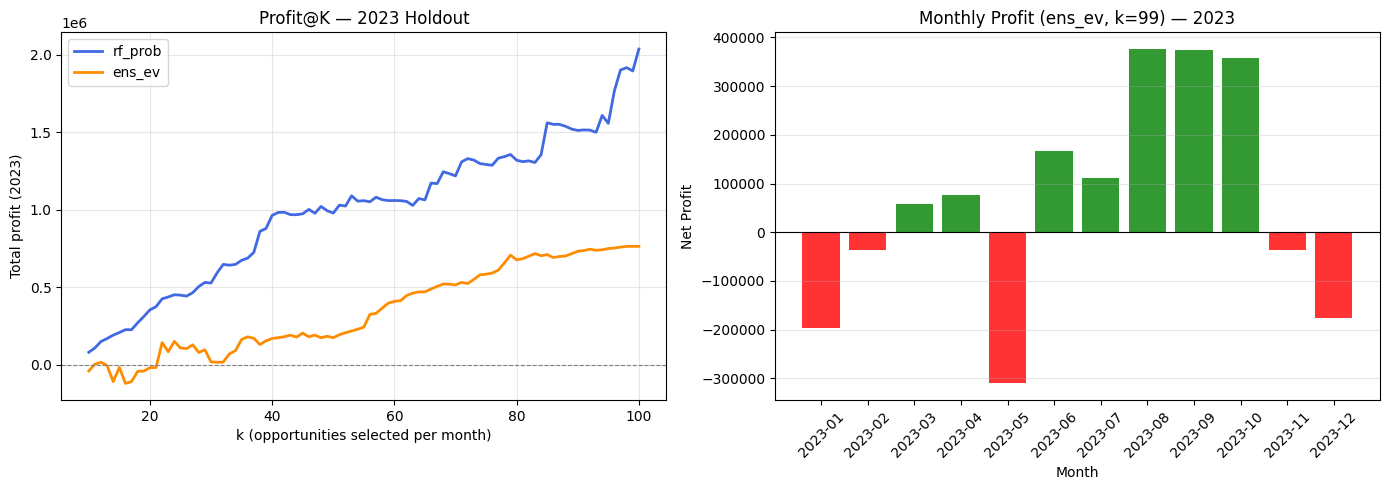

In [31]:
# ============================================================
# CELL 16 — PROFIT@K CURVE (2023 HOLDOUT)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Profit@K curve ---
ax = axes[0]
k_range = range(10, 101)
for score_col, color in zip(
    ["rf_prob", "ens_ev"],
    ["royalblue", "darkorange"]
):
    profits = [per_month_topk_profit(test_scored, score_col, k) for k in k_range]
    ax.plot(list(k_range), profits, label=score_col, color=color, lw=2)

ax.set_xlabel("k (opportunities selected per month)")
ax.set_ylabel("Total profit (2023)")
ax.set_title("Profit@K — 2023 Holdout")
ax.axhline(0, color="grey", lw=0.8, linestyle="--")
ax.legend()
ax.grid(alpha=0.3)

# --- Monthly profit breakdown (best ensemble) ---
ax2 = axes[1]
best_ens_k = results_2023["ens_ev"]["k"]
monthly_profits = []
for month, grp in test_scored.groupby(MONTH_COL):
    sel = grp.nlargest(best_ens_k, "ens_ev")
    monthly_profits.append({"month": month, "profit": sel["PROFIT"].sum()})

mp_df = pd.DataFrame(monthly_profits)
colors = ["green" if p >= 0 else "red" for p in mp_df["profit"]]
ax2.bar(mp_df["month"], mp_df["profit"], color=colors, alpha=0.8)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_xlabel("Month")
ax2.set_ylabel("Net Profit")
ax2.set_title(f"Monthly Profit (ens_ev, k={best_ens_k}) — 2023")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


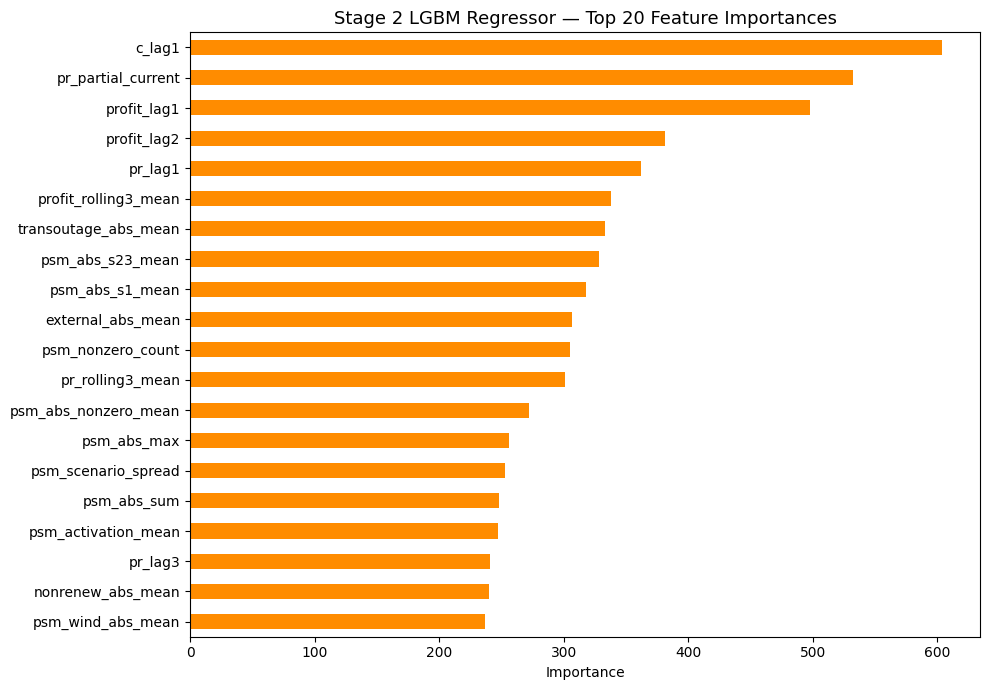

Top 10 Stage 1 features: ['pr_rolling3_mean', 'psm_activation_max', 'profitable_count_3m', 'pr_lag1', 'profit_rolling3_mean', 'psm_abs_nonzero_mean', 'profit_lag1', 'target_lag1', 'psm_abs_max', 'psm_abs_sum']
Top 10 Stage 2 features: ['c_lag1', 'pr_partial_current', 'profit_lag1', 'profit_lag2', 'pr_lag1', 'profit_rolling3_mean', 'transoutage_abs_mean', 'psm_abs_s23_mean', 'psm_abs_s1_mean', 'external_abs_mean']


In [32]:
# ============================================================
# CELL 17 — STAGE 2 FEATURE IMPORTANCE (LightGBM Regressor)
# ============================================================

fi_s2 = pd.Series(
    lgbm_reg.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
fi_s2.head(20).sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Stage 2 LGBM Regressor — Top 20 Feature Importances", fontsize=13)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

# Compare Stage 1 vs Stage 2 top features
print("Top 10 Stage 1 features:", fi.head(10).index.tolist())
print("Top 10 Stage 2 features:", fi_s2.head(10).index.tolist())


In [33]:
# ============================================================
# CELL 18 — ON-PEAK vs OFF-PEAK PERFORMANCE BREAKDOWN
# ============================================================

for peak_id, peak_name in [(0, "OFF-PEAK"), (1, "ON-PEAK")]:
    sub = test_scored[test_scored["PEAKID"] == peak_id]
    if len(sub) == 0:
        continue
    best_k_sub, _ = optimize_k(sub, "ens_ev", 10, 100)
    # Clip k to ensure we're within constraint per peak type (max 50 each for 100 total)
    best_k_sub = min(best_k_sub, 50)
    evaluate_full(sub, "ens_ev", best_k_sub, label=f"ens_ev [{peak_name}]")


ens_ev [OFF-PEAK]              | AUC=0.7772 | k= 50 | Profit=     543,603 | P=0.4417 R=0.1518 F1=0.2259
ens_ev [ON-PEAK]               | AUC=0.7529 | k= 50 | Profit=     195,072 | P=0.4217 R=0.1429 F1=0.2135


In [34]:
# ============================================================
# CELL 19 — FINAL MODEL: RETRAIN ON 2020-2023 COMBINED
# ============================================================
# For production/submission, we retrain on all available labeled data.

print("Retraining Stage 1 RF on full 2020-2023 data...")
all_df = full_df[full_df[MONTH_COL] <= TEST_END].copy()

final_rf = RandomForestClassifier(
    **best_rf_params,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)
final_rf.fit(all_df[FEATURES], all_df["TARGET"])
print(f"  Final RF trained on {len(all_df):,} rows.")

print("\nRetraining Stage 2 regressors on all positives from 2020-2023...")
all_positives = all_df[all_df["TARGET"] == 1].copy()

final_lgbm = lgb.LGBMRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.04,
    num_leaves=31, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, n_jobs=-1, verbosity=-1
)
final_lgbm.fit(all_positives[FEATURES], all_positives["PROFIT"])

final_xgb = XGBRegressor(
    n_estimators=500, max_depth=5, learning_rate=0.04,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, n_jobs=-1, tree_method="hist", verbosity=0
)
final_xgb.fit(all_positives[FEATURES], all_positives["PROFIT"])

print(f"  Stage 2 trained on {len(all_positives):,} positives.")
print("\nFinal models ready.")


Retraining Stage 1 RF on full 2020-2023 data...
  Final RF trained on 211,510 rows.

Retraining Stage 2 regressors on all positives from 2020-2023...
  Stage 2 trained on 15,406 positives.

Final models ready.


In [35]:
# ============================================================
# CELL 20 — INFERENCE FUNCTION
# ============================================================
# Given a DataFrame for a target month, apply the 2-stage pipeline
# and return up to k opportunities (10 ≤ k ≤ 100).

def select_opportunities(df_month: pd.DataFrame,
                         rf_model, lgbm_model, xgb_model,
                         feature_cols: list,
                         k_per_month: int = None,
                         k_min: int = 10,
                         k_max: int = 100) -> pd.DataFrame:
    """
    Apply the 2-stage pipeline to a pre-built feature DataFrame for one month.

    Parameters
    ----------
    df_month    : DataFrame with columns EID, MONTH, PEAKID, and all features
    rf_model    : Fitted Stage 1 RF classifier
    lgbm_model  : Fitted Stage 2 LightGBM regressor
    xgb_model   : Fitted Stage 2 XGBoost regressor
    feature_cols: List of feature column names
    k_per_month : Fixed k to select; if None, defaults to k_max (conservative)
    k_min, k_max: Constraint bounds

    Returns
    -------
    DataFrame with columns TARGET_MONTH, PEAK_TYPE, EID
    """
    df = df_month.copy()

    # Stage 1: classify
    df["rf_prob"] = rf_model.predict_proba(df[feature_cols])[:, 1]

    # Stage 2: predict profit magnitude
    lgbm_pred = lgbm_model.predict(df[feature_cols])
    xgb_pred  = xgb_model.predict(df[feature_cols])
    ens_pred  = (lgbm_pred + xgb_pred) / 2.0

    # Expected value score
    df["ens_ev"] = df["rf_prob"] * np.maximum(0, ens_pred)

    # Select top k by EV score
    k = k_per_month if k_per_month is not None else k_max
    k = int(np.clip(k, k_min, k_max))

    selected = df.nlargest(k, "ens_ev")[["EID", MONTH_COL, "PEAKID"]].copy()

    # Map PEAKID → PEAK_TYPE
    selected["PEAK_TYPE"]    = selected["PEAKID"].map({0: "OFF", 1: "ON"})
    selected["TARGET_MONTH"] = selected[MONTH_COL]

    return selected[["TARGET_MONTH", "PEAK_TYPE", "EID"]].drop_duplicates()


print("Inference function defined.")
print("Usage: select_opportunities(df_for_month, final_rf, final_lgbm, final_xgb, FEATURES)")


Inference function defined.
Usage: select_opportunities(df_for_month, final_rf, final_lgbm, final_xgb, FEATURES)


In [36]:
# ============================================================
# CELL 21 — GENERATE opportunities.csv (DEMO ON 2023 HOLDOUT)
# ============================================================
# In main.py, this loop iterates over all months in [start_month, end_month].
# Here we demonstrate on the 2023 holdout using pre-built features.

all_selections = []

for month, grp in test_df.groupby(MONTH_COL):
    # In the real pipeline, features for month M+1 are built from data
    # available at cutoff (7th of month M).
    selected = select_opportunities(
        grp, final_rf, final_lgbm, final_xgb, FEATURES,
        k_per_month=None  # uses k_max=100; tune per your CV results
    )
    all_selections.append(selected)

opportunities_df = pd.concat(all_selections, ignore_index=True)

# Validate constraints
print("=== CONSTRAINT CHECK ===")
counts = opportunities_df.groupby("TARGET_MONTH").size()
print(f"Months with < 10 selections : {(counts < 10).sum()}")
print(f"Months with > 100 selections: {(counts > 100).sum()}")
print(f"Total opportunities         : {len(opportunities_df):,}")
print(f"Duplicates                  : {opportunities_df.duplicated().sum()}")
print()
print(opportunities_df.head(10))

# Save
output_path = "opportunities.csv"
opportunities_df.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")


=== CONSTRAINT CHECK ===
Months with < 10 selections : 0
Months with > 100 selections: 0
Total opportunities         : 1,200
Duplicates                  : 0

  TARGET_MONTH PEAK_TYPE   EID
0      2023-01        ON  3035
1      2023-01        ON  2832
2      2023-01       OFF  3035
3      2023-01       OFF  2832
4      2023-01        ON  5662
5      2023-01       OFF  1750
6      2023-01        ON  1750
7      2023-01        ON  7812
8      2023-01       OFF  1599
9      2023-01       OFF  5152

Saved to: opportunities.csv


In [37]:
# ============================================================
# CELL 22 — FINAL EVALUATION SUMMARY (2023 HOLDOUT)
# ============================================================

# Merge selections with ground truth
truth = test_df[["EID", MONTH_COL, "PEAKID", "TARGET", "PROFIT"]].copy()
truth["TARGET_MONTH"] = truth[MONTH_COL]
truth["PEAK_TYPE"]    = truth["PEAKID"].map({0: "OFF", 1: "ON"})

results_merged = opportunities_df.merge(
    truth[["TARGET_MONTH", "PEAK_TYPE", "EID", "TARGET", "PROFIT"]],
    on=["TARGET_MONTH", "PEAK_TYPE", "EID"],
    how="left"
).fillna({"TARGET": 0, "PROFIT": 0.0})

total_profit = results_merged["PROFIT"].sum()
n_selected   = len(results_merged)
n_profitable = results_merged["TARGET"].sum()

# F1 using all truth positives as FN pool
all_truth_positives = truth["TARGET"].sum()
tp = n_profitable
fp = n_selected - n_profitable
fn = all_truth_positives - tp

precision_final = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_final    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_final = (2 * precision_final * recall_final /
            (precision_final + recall_final)
            if (precision_final + recall_final) > 0 else 0)

print("╔══════════════════════════════════════════════════╗")
print("║          FINAL 2023 HOLDOUT EVALUATION           ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Total opportunities selected : {n_selected:>8,}          ║")
print(f"║  Profitable (TP)              : {int(n_profitable):>8,}          ║")
print(f"║  False positives (FP)         : {int(fp):>8,}          ║")
print(f"║  False negatives (FN)         : {int(fn):>8,}          ║")
print(f"║  Precision                    : {precision_final:>8.4f}          ║")
print(f"║  Recall                       : {recall_final:>8.4f}          ║")
print(f"║  F1-score                     : {f1_final:>8.4f}          ║")
print(f"║  Total net profit             : {total_profit:>12,.2f}      ║")
print("╚══════════════════════════════════════════════════╝")

# Monthly breakdown
print("\n── Monthly breakdown ──")
monthly = results_merged.groupby("TARGET_MONTH").agg(
    selected=("EID", "count"),
    profitable=("TARGET", "sum"),
    profit=("PROFIT", "sum")
).reset_index()
monthly["precision"] = monthly["profitable"] / monthly["selected"]
print(monthly.to_string(index=False))


╔══════════════════════════════════════════════════╗
║          FINAL 2023 HOLDOUT EVALUATION           ║
╠══════════════════════════════════════════════════╣
║  Total opportunities selected :    1,200          ║
║  Profitable (TP)              :      369          ║
║  False positives (FP)         :      831          ║
║  False negatives (FN)         :    3,147          ║
║  Precision                    :   0.3075          ║
║  Recall                       :   0.1049          ║
║  F1-score                     :   0.1565          ║
║  Total net profit             :   983,275.57      ║
╚══════════════════════════════════════════════════╝

── Monthly breakdown ──
TARGET_MONTH  selected  profitable        profit  precision
     2023-01       100          20 -367,358.5006     0.2000
     2023-02       100          29  -86,407.0287     0.2900
     2023-03       100          39  -62,268.0665     0.3900
     2023-04       100          30   93,870.4132     0.3000
     2023-05       100         

In [38]:
# ============================================================
# CELL 20 — SAVE ALL MODELS & ARTIFACTS
# ============================================================
# Run this once after training. Saves everything needed to skip
# retraining entirely: models, OOF data, CV results, feature list.
#
# Produces:
#   models/
#     final_rf.joblib          — Stage 1 RF (fit on 2020-2023)
#     final_lgbm.joblib        — Stage 2 LightGBM (fit on 2020-2023)
#     final_xgb.joblib         — Stage 2 XGBoost (fit on 2020-2023)
#     best_rf_params.json      — Best RF hyperparameters
#     rf_dev_results.parquet   — Full CV tuning results table
#     stage2_oof_df.parquet    — OOF dataframe used to train Stage 2
#     features.json            — Feature list (guards against column drift)
#     config.json              — best_k and other scalar settings

import joblib
from pathlib import Path

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

# --- Models ---
joblib.dump(final_rf,   MODELS_DIR / "final_rf.joblib",   compress=3)
joblib.dump(final_lgbm, MODELS_DIR / "final_lgbm.joblib", compress=3)
joblib.dump(final_xgb,  MODELS_DIR / "final_xgb.joblib",  compress=3)
print("Models saved.")

# --- Hyperparameters & CV results ---
import json as _json
with open(MODELS_DIR / "best_rf_params.json", "w") as f:
    _json.dump(best_rf_params, f, indent=2)

rf_dev_results.to_parquet(MODELS_DIR / "rf_dev_results.parquet", index=False)
print("CV results saved.")

# --- OOF dataframe (Stage 2 training data) ---
stage2_oof_df.to_parquet(MODELS_DIR / "stage2_oof_df.parquet", index=False)
print("OOF dataframe saved.")

# --- Feature list & scalar config ---
best_k_final = results_2023["ens_ev"]["k"]   # best k from 2023 holdout evaluation

with open(MODELS_DIR / "features.json", "w") as f:
    _json.dump(FEATURES, f, indent=2)

with open(MODELS_DIR / "config.json", "w") as f:
    _json.dump({
        "best_k": best_k_final,
        "best_rf_config_id": best_rf_config_id,
        "train_end": TEST_END,
        "month_col": MONTH_COL,
    }, f, indent=2)

print("Feature list & config saved.")
print(f"\nAll artifacts written to: {MODELS_DIR.resolve()}")
print("\nDirectory contents:")
for p in sorted(MODELS_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<35s} {size_kb:>8.1f} KB")


Models saved.
CV results saved.
OOF dataframe saved.
Feature list & config saved.

All artifacts written to: C:\Users\Rachid\Downloads\models

Directory contents:
  best_rf_params.json                      0.1 KB
  config.json                              0.1 KB
  features.json                            1.2 KB
  final_lgbm.joblib                      408.0 KB
  final_rf.joblib                       4385.1 KB
  final_xgb.joblib                       367.7 KB
  model_artifacts_stage_2_features_oof      0.0 KB
  Models_artifacts_Stage2.zip          27863.6 KB
  models_artifacts_stage_2                 0.0 KB
  models_artifacts_stage_2.zip          5151.4 KB
  rf_dev_results.parquet                   5.8 KB
  stage2_oof_df.parquet                25286.9 KB
